In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bhanupratapbiswas/house-price-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'house-price-prediction' dataset.
Path to dataset files: /kaggle/input/house-price-prediction


In [5]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

import joblib

In [8]:
import os

# List the contents of the downloaded path to identify the correct CSV file
print("Contents of dataset directory:", os.listdir(path))

# Assuming the CSV file is named 'Housing.csv' inside the downloaded directory, or adjust based on actual contents.
# If the CSV is in a subdirectory, you'll need to adjust csv_file_path accordingly.
# For example, if it's in a subfolder named 'data': csv_file_path = os.path.join(path, 'data', 'Housing.csv')
# For now, let's try the common names, or user might need to specify it.

# Based on common Kaggle datasets, let's assume the CSV file is directly in 'path' but might have a different name.
# If 'Housing.csv' is still not found, further inspection of os.listdir(path) will be needed.
# For now, let's assume 'Housing.csv' is the correct name once we have identified it.

# Let's try to find a .csv file in the path or its immediate subdirectories
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if not csv_files:
    # If no CSV found directly, check one level deeper for common subdirectories like 'data'
    for root, dirs, files in os.walk(path):
        for file in files:
            if file.endswith('.csv'):
                csv_files.append(os.path.join(root, file))
                break # Assuming only one main CSV file is needed
        if csv_files: break # Stop after finding the first CSV

if csv_files:
    csv_file_path = csv_files[0] # Take the first CSV file found
    # If it's not a full path (e.g. if it was found directly in `path`)
    if not os.path.isabs(csv_file_path):
        csv_file_path = os.path.join(path, csv_file_path)
    print(f"Attempting to load: {csv_file_path}")
    df = pd.read_csv(csv_file_path)
    print(df.shape)
    df.info()
    df.describe()
else:
    print("Error: No CSV file found in the dataset directory or its immediate subdirectories.")
    print("Please manually specify the correct path to your CSV file.")


Contents of dataset directory: ['data.csv']
Attempting to load: /kaggle/input/house-price-prediction/data.csv
(4600, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600

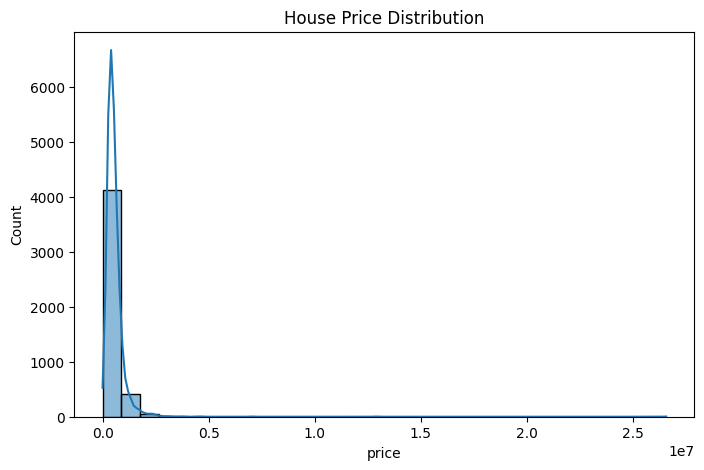

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=30, kde=True)

plt.title("House Price Distribution")

plt.show()

In [10]:
df["price"] = np.log1p(df["price"])

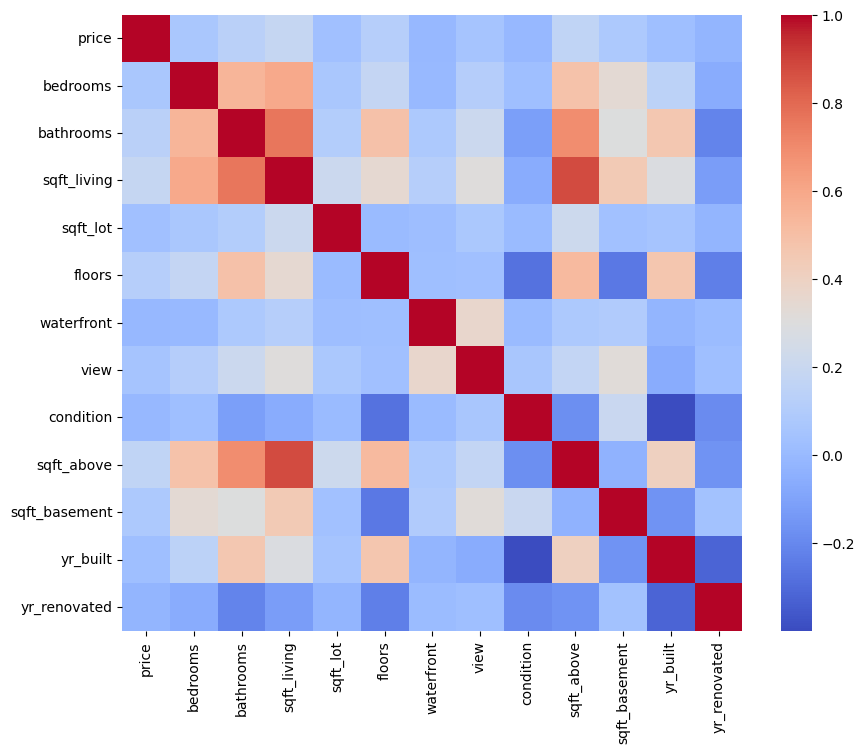

In [11]:
plt.figure(figsize=(10,8))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr, cmap="coolwarm")

plt.show()

In [13]:
X = df.drop('price', axis=1)

numeric_features = X.select_dtypes(include=np.number).columns

categorical_features = X.select_dtypes(exclude=np.number).columns

print("Numeric Features:", numeric_features)

print("Categorical Features:", categorical_features)

Numeric Features: Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated'],
      dtype='object')
Categorical Features: Index(['date', 'street', 'city', 'statezip', 'country'], dtype='object')


In [14]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [16]:
lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [18]:
print("Linear Regression Model Evaluation:")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, lr_pred):.2f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, lr_pred):.2f}")
print(f"R-squared (R2): {r2_score(y_test, lr_pred):.2f}")

Linear Regression Model Evaluation:
Mean Squared Error (MSE): 1.93
Mean Absolute Error (MAE): 0.44
R-squared (R2): 0.01


In [20]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ))
])
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

KeyboardInterrupt: 

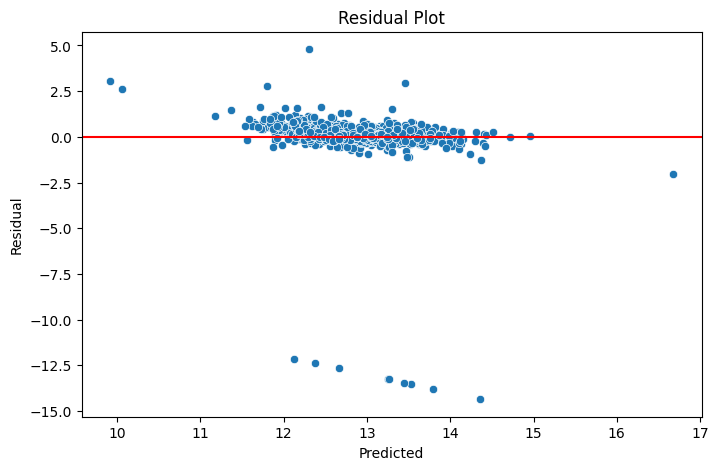

In [23]:
best_pred = lr_pred

residuals = y_test - best_pred

plt.figure(figsize=(8,5))

sns.scatterplot(x=best_pred, y=residuals)

plt.axhline(0,color="red")

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

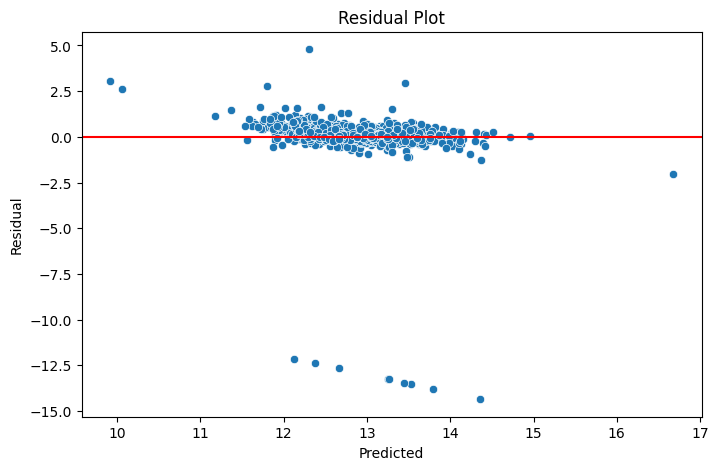

In [25]:
best_pred = lr_pred

residuals = y_test - best_pred

plt.figure(figsize=(8,5))

sns.scatterplot(x=best_pred, y=residuals)

plt.axhline(0,color="red")

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()